# 1.Learning about numpy


### 1. different kinds of arrays


In [82]:
import numpy as np
import matplotlib.pyplot as plt

a1 = np.array([4, 5, 7, 8])
a2 = np.zeros(10) # 10 element array with all zeros
a3 = np.ones(10) # 10 elements with all ones
a4 = np.random.rand(10) # random values between 0 and 1
a5 = np.random.randn(10) #gaussian
a6 = np.linspace(0, 10, 100) # 10 elements with all no. 0 to 10 and 100 elem
a7 = np.arange(0, 10, 0.1) # all elem  < 10 and spacing of 0.1
a7 #upto 9.9 not 10

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
       2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
       3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1,
       5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3, 6.4,
       6.5, 6.6, 6.7, 6.8, 6.9, 7. , 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7,
       7.8, 7.9, 8. , 8.1, 8.2, 8.3, 8.4, 8.5, 8.6, 8.7, 8.8, 8.9, 9. ,
       9.1, 9.2, 9.3, 9.4, 9.5, 9.6, 9.7, 9.8, 9.9])


### 2. Array operations

In [83]:
2* a1 # all elem doubled

array([ 8, 10, 14, 16])

In [84]:
1/a1 # all reciprocal of elem of a1

array([0.25      , 0.2       , 0.14285714, 0.125     ])

In [85]:
# printing elem in a1 > 6
a1[a1 > 6]

array([7, 8])

In [86]:
# find all elem in list whose name starts with j
names = np.array(['jack', 'jill', 'wolves', 'kirmada'])
#lambda function
f = lambda s: s[0].lower() # if we pass f as a string, it'll return the first letter. if list it will return the 1st element and this will not discriminate btw capas or small
f(['bigboi', 'td']) # bigboi
f('bigboi') # b
first_letter_j = np.vectorize(f)(names) == 'j'  #gives true or false accd to index
names[first_letter_j]

array(['jack', 'jill'], dtype='<U7')

## 3. calculus and statistics

In [87]:
a1 = 2*np.random.randn(10000) + 10 #gaussian distribution
print (np.mean(a1)) # mean of data nearly 10
print (np.std(a1)) #std of data shud be near 2
print (np.percentile(a1, 80)) # the no. which is nore than 80% of data in the dist

10.040922577627471
2.0039243307177923
11.742164491177347


## 4. integrals and derivatives

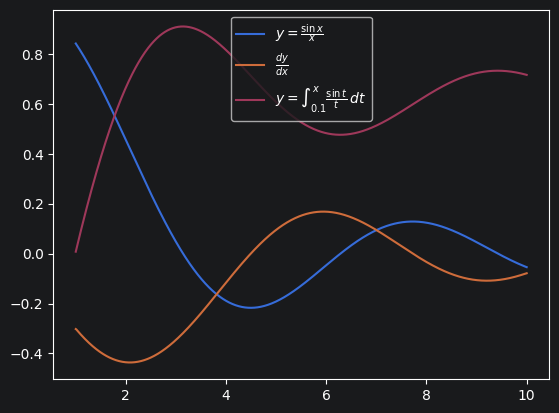

In [88]:
x = np.linspace(1, 10 , 1000)
y = np.sin(x)/x #better to visualise
dydx = np.gradient(y, x) #gradient of y with respect to x
# to find integral to some random value we find cumulative sum
int_y = np.cumsum(y)*(x[1]-x[0])

plt.plot(x, y, label=r'$y = \frac{\sin x}{x}$')
plt.plot(x, dydx, label=r'$\frac{dy}{dx}$')
plt.plot(x, int_y, label=r'$y = \int_{0.1}^{x} \frac{\sin t}{t} \, dt$')
plt.legend()
plt.show()

## Examples

### Question 1:

Let $y = e^{-x/10} \sin(x)$. Consider 10000 $x$ intervals in the range $[0, 10]$

1. Plot the function $y$ vs. $x$ in the range $[0, 10]$
2. Compute the mean and standard deviation of $y$ for $x$ values in $[4, 7]$
3. For $x$ in the range $[4, 7]$, find the value $y_m$ such that 80% of $y$ values are less than $y_m$
4. Plot $dy/dx$ vs $x$
5. Find the locations where $dy/dx = 0$

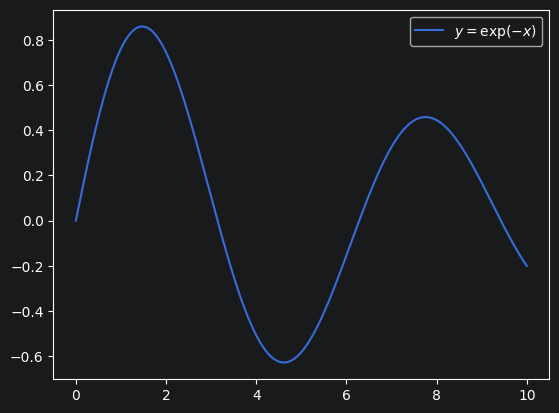

-0.2956362863932012
0.3144532369395424
0.061372680560897265


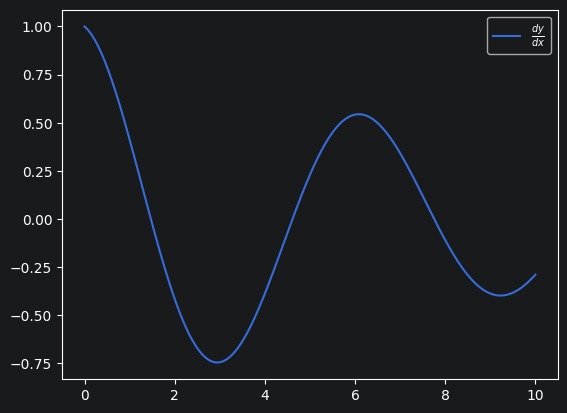

[1.47114711 4.61346135 7.75477548]


In [89]:
x= np.linspace(0, 10, 10000)
y = np.exp(-x/10) * np.sin(x)
#question 1
plt.plot(x, y, label=r'$y = \exp(-x)$')
plt.legend()
plt.show()
#question 2
#merging conditions to get new set
y1 = y[(x >= 4)* (x <= 7)]
x1 = x[(x >= 4) * (x <= 7)]
print(np.mean(y1))
print(np.std(y1))
# question 3
print (np.percentile(y1, 80))
dydx = np.gradient(y, x)
plt.plot(x, dydx, label=r'$\frac{dy}{dx}$')
plt.legend()
plt.show()
#question 5
# i can use a for loop but im too lazy
dydx_0 = dydx[1:] * dydx[:-1] # only after 1st elem amd all b4 last elements multiplied
print (x[1:][(dydx_0 < 0)])

### question 2
find sum of all elems between 1 to 10000 both inclusive which are not divisible by 4 or 7

In [90]:
print(np.arange(0, 10001, 1)[(np.arange(0, 10001, 1)%4 != 0)*(np.arange(0, 10001, 1)%7 != 0)].sum())

32147142


### Question 3:

Consider the flower petal $r(\theta) = 1 + \frac{3}{4}\sin(3\theta)$ for $0 \leq \theta \leq 2\pi$

1. Make a plot of the flower (find x and y points)
2. Compute the area using the calculus formula $A = \int_0^{2\pi} \frac{1}{2} r^2 d\theta$
3. Compute the arclength using the calculus formula $L = \int_0^{2\pi} \sqrt{r^2 + \left(\frac{dr}{d\theta}\right)^2} \, d\theta$

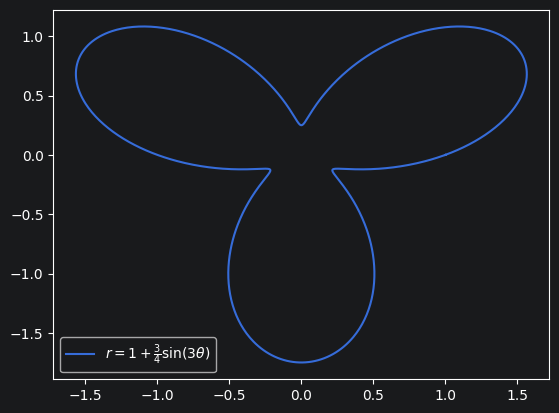

In [91]:
# question 1
theta = np.linspace(0, 2*np.pi, 1000)
def radial(the):
    return 1 + 0.75 * np.sin(3*the)
r = radial(theta)
x = r * np.cos(theta)
y = r * np.sin(theta)
plt.plot(x, y, label=r'$r = 1 + \frac{3}{4}  \sin (3 \theta$)')
plt.legend()
plt.show()

In [92]:
# FINDING AREA
a = 0.5 * np.sum(r**2) * (theta[1]-theta[0])
print(a)

4.028310324802903


In [93]:
# perimeter
def darc(r, drdtheta):
    return np.sqrt(r*r + drdtheta**2)
drdt = np.gradient(r, theta)
r1 = darc(r, drdt)
s = np.sum(r1)*(theta[1] - theta[0])
print (s)

11.640021569013866


## Multidimensional arrays

creating multidimensional array

In [94]:
a1 = np.array([[4, 5, 6], [1, 2, 3], [6, 7, 9]])
a1

array([[4, 5, 6],
       [1, 2, 3],
       [6, 7, 9]])

flattening the array

In [95]:
x = np.ravel(a1)
print(x) # row 1 then row 2 then row 3

[4 5 6 1 2 3 6 7 9]


In [96]:
#creating boolean array
a1 > 5

array([[False, False,  True],
       [False, False, False],
       [ True,  True,  True]])

In [97]:
a2 = np.random.randn(3,3)
a2

array([[ 1.2509232 ,  1.6294455 ,  0.74773877],
       [ 0.20948696, -0.63388339,  1.06100819],
       [ 0.45112381, -0.32350046,  0.58750301]])

In [98]:
a2[a1>5] # here actually flattens

array([ 0.74773877,  0.45112381, -0.32350046,  0.58750301])

In [99]:
a1[0]

array([4, 5, 6])

In [100]:
a1[:,1] # this 2nd elem rep column no.


array([5, 2, 7])

In [101]:
a1[0, :] # same as a1[0]

array([4, 5, 6])

In [102]:
a1[1:,0] # i want the column but the row index starts from 1

array([1, 6])

## Dealing with 2D function

functions in 2d

In [103]:
x = np.linspace(0, 10, 1000)
y = np.linspace(0, 10, 1000)


meshgrids

In [104]:
xv, yv = np.meshgrid(x, y) # xv contains all rows of x and yv all columns of y
xv #yv has 2 columns and 3 rows whereas xv also the same
# remember like no, of x coordinates and no. of y coordinates

array([[ 0.        ,  0.01001001,  0.02002002, ...,  9.97997998,
         9.98998999, 10.        ],
       [ 0.        ,  0.01001001,  0.02002002, ...,  9.97997998,
         9.98998999, 10.        ],
       [ 0.        ,  0.01001001,  0.02002002, ...,  9.97997998,
         9.98998999, 10.        ],
       ...,
       [ 0.        ,  0.01001001,  0.02002002, ...,  9.97997998,
         9.98998999, 10.        ],
       [ 0.        ,  0.01001001,  0.02002002, ...,  9.97997998,
         9.98998999, 10.        ],
       [ 0.        ,  0.01001001,  0.02002002, ...,  9.97997998,
         9.98998999, 10.        ]], shape=(1000, 1000))

In [105]:
zv = xv**2 + yv**2

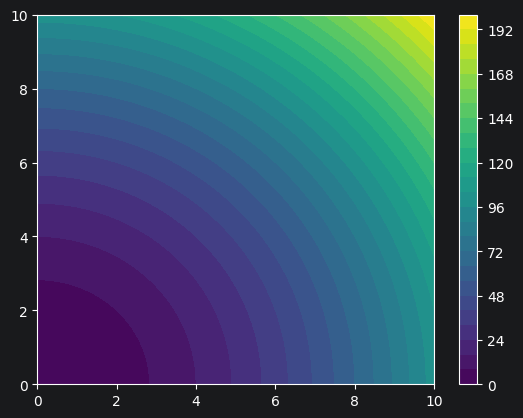

In [106]:
# here we use contour plot
plt.contourf(xv, yv, zv, levels = 30)
plt.colorbar()
plt.show()

### Basic tony operations

### 1. Matrix multiplication

In [107]:
A =np.array([[1, 2, 3],[4, 5, 10], [11, 13, 67]])
b1 = np.array([1, 3, 4])

# for multip. we use @
A@b1

array([ 19,  59, 318])

In [108]:
# transpose of A
A.T

array([[ 1,  4, 11],
       [ 2,  5, 13],
       [ 3, 10, 67]])

In [109]:
b2 = np.array([5, 3, 9])
print(np.dot(b1, b2))
print(np.cross(b1, b2))


50
[ 15  11 -12]


### solving linear equations



$$3x + 2y + z = 4$$
$$5x - 5y + 4z = 3$$
$$6x + z = 0$$

In [110]:
A = np.array([[3, 2, 1], [5, -5, 4], [6, 0, 1]])
c = np.array([4, 3, 0])
np.linalg.solve(A, c)

array([-0.49056604,  1.26415094,  2.94339623])

In [111]:
#eigen values of A
A = np.array([[4,2,2],[2,4,2],[2,2,4]])
np.linalg.eigvals(A) # eigenvalues
np.linalg.eig(A) # EIGENVALUES + EIGEN VECTORS

EigResult(eigenvalues=array([2., 8., 2.]), eigenvectors=array([[-0.81649658,  0.57735027, -0.32444284],
       [ 0.40824829,  0.57735027, -0.48666426],
       [ 0.40824829,  0.57735027,  0.81110711]]))

In [112]:
w, v = np.linalg.eig(A)
print (w) # eigvals
print(v) #eigvect columns are eigen vectors
v1 = v[:, 0]
print (A@v1)
print (v1 * w[0]) # both turns out to be equal

[2. 8. 2.]
[[-0.81649658  0.57735027 -0.32444284]
 [ 0.40824829  0.57735027 -0.48666426]
 [ 0.40824829  0.57735027  0.81110711]]
[-1.63299316  0.81649658  0.81649658]
[-1.63299316  0.81649658  0.81649658]


## Examples

### Question 1

Let $f(x, y) = e^{-(x^2 + y^2)} \cdot \sin(x)$ for $-2 \leq x \leq 2$ and $-2 \leq y \leq 2$

1. Make a contour plot of $f$
2. Find the volume $|f(x, y)|$ in the specified $x$ and $y$ range
3. Find the volume $|f(x, y)|$ only in the region where $\sqrt{x^2 + y^2} > 0.5$

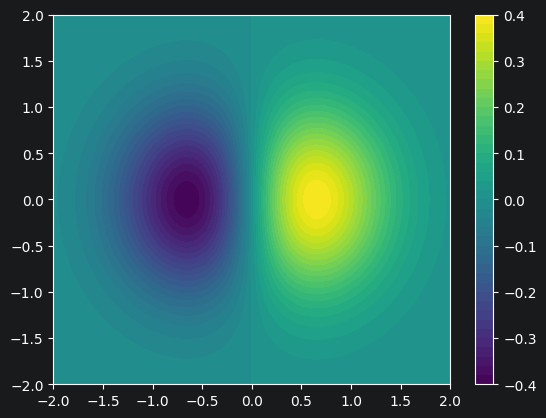

In [113]:
# question 1
x = np.linspace(-2, 2, 1000)
y = np.linspace(-2, 2, 1000)
xv, yv = np.meshgrid(x, y)
zv = np.exp(-xv**2 - yv**2) * np.sin(xv)
plt.contourf(xv, yv, zv, levels = 40)
plt.colorbar()
plt.show()

In [114]:
# part 2
print(np.abs(zv.ravel()).sum()* np.diff(x)[0] * np.diff(y)[0])

1.4861858145124311


In [115]:
req = np.sqrt(xv**2 + yv**2) > 0.5

In [116]:
zreq = zv[req]
print (np.abs(zreq).sum()*np.diff(x)[0] * np.diff(y)[0])

1.3447652930203169


## Question 2
After examining a circuit full of resistors, you find that the voltage at 4 specified points is given by

$$3V_1 + 2V_2 + 3V_3 + 10V_4 = 4$$

$$2V_1 - 2V_2 + 5V_3 + 8V_4 = 1$$

$$3V_1 + 3V_2 + 4V_3 + 9V_4 = 3$$

$$3V_1 + 4V_2 - 3V_3 - 7V_4 = 2$$

Find all the voltages

In [117]:
A = np.array([[3, 2, 3, 10], [2, -2, 5, 8], [3, 3, 4, 9], [3, 4, -3, -7]])
i = np.array([4, 1, 3, 2])
np.linalg.solve(A, i)

array([ 0.78378378,  0.03603604, -0.67567568,  0.36036036])

### Question 3 (tougher)

An electric field is given by $\vec{E}(z, t) = E_0 \cos(z - t)\hat{x} + 2E_0 \cos(z - t + \pi/2)\hat{y}$

1. Find the magnetic field for all $z \in [0, 4\pi]$ and $t \in [0, 10]$ using $c\vec{B}(z, t) = \hat{z} \times \vec{E}(z, t)$
2. Compute the Poynting vector $\vec{S} = \vec{E} \times \vec{B}$ for all $z$ and $t$

In [118]:
z= np.linspace(0, 4* np.pi, 1000)
t = np.linspace(0, 10, 1000)
zv, tv = np.meshgrid(z, t)
ph = zv-tv
E0 = 1
Ex = E0 * np.cos(ph)
Ey = 2* E0 * np.cos(ph + np.pi/2)
c = 1
Ez = Ex * 0


### ploting
plot $E_x$ as a function of t at z = 0

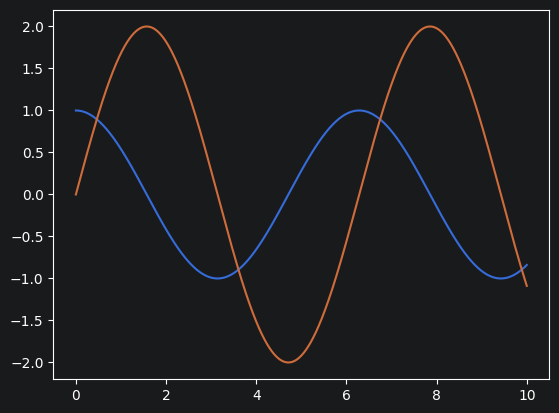

In [119]:
Ex_atz0 = Ex[:, 0]

plt.plot(t, Ex_atz0)
plt.plot(t, Ey[:, 0])
plt.show()

Plot $E_x$ as a function of z at t = 0

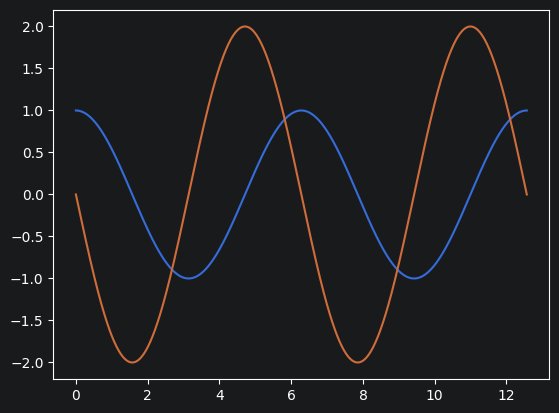

In [120]:
plt.plot(z, Ex[0])
plt.plot(z, Ey[0])
plt.show()

Now finding magnetic field

### Question 4 (tougher)

Find the solutions to $\left(\frac{d^2}{dx^2} + (10x)^2\right)f = \lambda f$ with boundary conditions $f(0) = f(1) = 0$

- use the eigenvalue method and the fact that $\frac{d^2f}{dx^2} \approx \frac{f_{i+1} + f_{i-1} - 2f_i}{\Delta x^2}$ where $f_i = f(i\Delta x)$ and $i$ is an integer.

In [121]:
N = 1000
x = np.linspace(0,1,N+1)
dx = x[1]-x[0]

main_diag = -2*np.ones(N-1)
off_diag = np.ones(N-2)
derivative_matrix = (np.diag(main_diag) + np.diag(off_diag, k=1)+ np.diag(off_diag, k=-1))/dx**2
derivative_matrix


array([[-2000000.,  1000000.,        0., ...,        0.,        0.,
               0.],
       [ 1000000., -2000000.,  1000000., ...,        0.,        0.,
               0.],
       [       0.,  1000000., -2000000., ...,        0.,        0.,
               0.],
       ...,
       [       0.,        0.,        0., ..., -2000000.,  1000000.,
               0.],
       [       0.,        0.,        0., ...,  1000000., -2000000.,
         1000000.],
       [       0.,        0.,        0., ...,        0.,  1000000.,
        -2000000.]], shape=(999, 999))

In [122]:
x2_matrix = np.diag((10*x[1:-1])**2)
LHS_matrix = derivative_matrix + x2_matrix


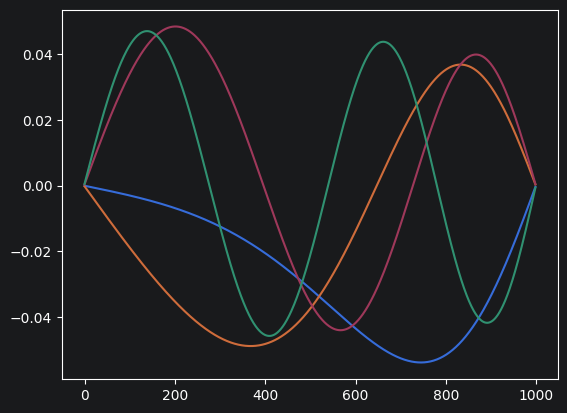

In [126]:
eigvals, eigvecs = np.linalg.eigh(LHS_matrix)
#eigvalks come in descending order
eigvals[-1]
plt.plot(eigvecs[:, -1])
plt.plot(eigvecs[:, -2])
plt.plot(eigvecs[:, -3])
plt.plot(eigvecs[:, -4])
